# Fase 1 - Definición y orientación de la situación
## Proyecto ABP: Clasificación de especies del dataset Iris

**Asignatura:** Machine Learning I  
**Notebook:** `F1_Definicion_Iris.ipynb`  
**Integrantes:** Jennifer Nilo, Patricio Núñez  
**Grupo:** 8  
**Fecha:** 09-08-2026  
**Repositorio:**  https://github.com/pnunezcarreno/machinelearning1  
**Ruta del notebook en el repositorio:** /notebooks/F1_Definicion.ipynb  
**Dataset:** Iris, cargado desde `sklearn.datasets`  

**Propósito de la fase:** formalizar el problema analítico, caracterizar los datos disponibles, seleccionar el tipo de aprendizaje y vincular el trabajo con las etapas de la metodología KDD. Cabe destacar que en esta fase **no se entrena ningún modelo**.

## Índice del notebook

1. Introducción y contextualización  
2. Definición de la problemática y objetivos  
3. Clasificación del tipo de aprendizaje  
4. Relación entre Machine Learning y KDD  
5. Configuración del entorno  
6. Selección y carga de los datos  
7. Preprocesamiento y calidad de datos  
8. Transformación y exploración inicial  
9. Comparación de enfoques  
10. Documentación de decisiones técnicas  
11. Conclusiones y proyección  
12. Referencias

# 1. Introducción y contextualización

El dataset **Iris** contiene mediciones morfológicas de flores pertenecientes a tres especies: *setosa*, *versicolor* y *virginica*. Para cada observación se registran el largo y el ancho del sépalo y del pétalo.

El análisis consiste en determinar si estas mediciones contienen información suficiente para diferenciar las especies. El objetivo de esta fase es establecer si el problema puede formularse como una tarea de Machine Learning y dejar preparada una base técnica y metodológica coherente para las fases posteriores.

La relación inicial entre los elementos del proyecto es la siguiente:

- **Problema:** identificar la especie de una flor a partir de sus mediciones.
- **Datos disponibles:** variables numéricas continuas y una etiqueta categórica conocida.
- **Propósito:** predecir una categoría entre tres clases posibles.
- **Enfoque esperado:** aprendizaje supervisado de clasificación multiclase.

# 2. Definición de la problemática y objetivos

## 2.1 Formulación del problema

Se requiere analizar las características morfológicas registradas en el dataset Iris y evaluar su congruencia para construir, en fases posteriores, un sistema capaz de clasificar una flor en una de tres especies conocidas.

## 2.2 Pregunta analítica

**¿Es posible identificar la especie de una flor Iris a partir del largo y ancho de sus sépalos y pétalos?**

## 2.3 Objetivo general

Definir y fundamentar un problema de clasificación supervisada orientado a identificar la especie de una flor Iris mediante sus características morfológicas, verificando previamente la estructura, calidad y utilidad inicial de los datos.

## 2.4 Objetivos específicos

1. Cargar y describir la estructura del dataset Iris.
2. Identificar las variables predictoras y la variable objetivo.
3. Verificar tipos de datos, valores nulos, duplicados y distribución de clases.
4. Explorar estadísticamente las variables numéricas y sus relaciones.
5. Justificar el aprendizaje supervisado como enfoque metodológico.
6. Relacionar las actividades realizadas con las etapas de KDD.
7. Documentar las decisiones técnicas que orientarán las fases posteriores.

## 2.5 Alcance

Esta fase contempla definición, selección, revisión de calidad, transformación exploratoria e interpretación inicial. No contempla separación entrenamiento/prueba, ajuste de hiperparámetros, entrenamiento ni evaluación de modelos.

# 3. Clasificación del tipo de aprendizaje

Se selecciona **aprendizaje supervisado**, específicamente una tarea de **clasificación multiclase**, debido a que:

- Cada registro posee variables de entrada y una etiqueta conocida.
- La variable objetivo es `Species`.
- `Species` es una variable categórica nominal con tres clases.
- El propósito futuro es asignar una de esas clases a nuevas observaciones.

### Variables del problema

- **Predictoras (`X`)**: `Sepal.Length`, `Sepal.Width`, `Petal.Length`, `Petal.Width`.
- **Objetivo (`y`)**: `Species`.
- **Tipo de datos de entrada**: numéricos continuos.
- **Tipo de variable objetivo**: categórica nominal.

No se selecciona aprendizaje no supervisado porque existen etiquetas conocidas y el objetivo no es descubrir grupos desconocidos. Tampoco se selecciona aprendizaje por refuerzo porque no existe un agente que tome acciones, reciba recompensas y aprenda mediante interacción secuencial.

# 4. Relación entre Machine Learning y metodología KDD

| Etapa KDD | Función en este proyecto |
|---|---|
| **Selección** | Elegir el dataset Iris y distinguir variables predictoras y objetivo. |
| **Preprocesamiento** | Revisar tipos, valores nulos, duplicados, consistencia y posibles atípicos. |
| **Transformación** | Preparar variables y evaluar transformaciones como escalamiento, sin comprometer aún una decisión definitiva. |
| **Minería de datos** | En fases posteriores se entrenarán algoritmos de clasificación supervisada. En Fase 1 solo se define su función. |
| **Interpretación / evaluación** | Analizar si los resultados futuros responden la pregunta analítica y son coherentes con los datos. |

El modelo de Machine Learning será un componente dentro del proceso KDD, no el proceso completo. Su calidad dependerá de las decisiones adoptadas antes y después del entrenamiento.

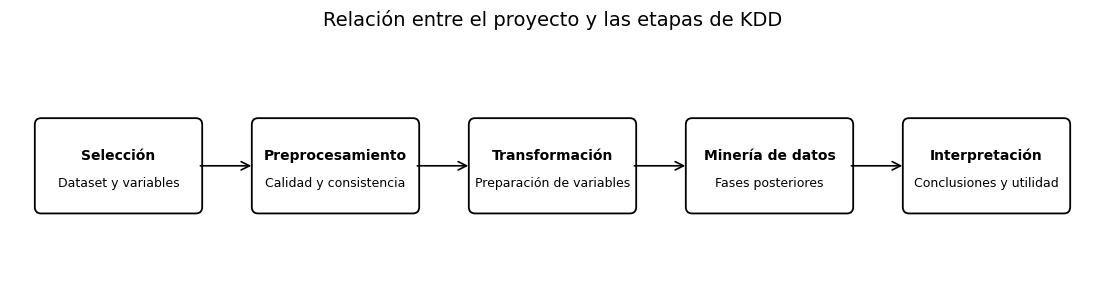

In [1]:
# Diagrama simple del flujo KDD para esta fase
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

etapas = [
    ("Selección", "Dataset y variables"),
    ("Preprocesamiento", "Calidad y consistencia"),
    ("Transformación", "Preparación de variables"),
    ("Minería de datos", "Fases posteriores"),
    ("Interpretación", "Conclusiones y utilidad")
]

fig, ax = plt.subplots(figsize=(14, 3.2))
ax.set_xlim(0, 14)
ax.set_ylim(0, 3)
ax.axis("off")

x_positions = [0.4, 3.2, 6.0, 8.8, 11.6]
for i, ((titulo, detalle), x) in enumerate(zip(etapas, x_positions)):
    box = FancyBboxPatch(
        (x, 1), 2.0, 1.0,
        boxstyle="round,pad=0.08",
        linewidth=1.3,
        facecolor="white"
    )
    ax.add_patch(box)
    ax.text(x + 1, 1.62, titulo, ha="center", va="center", fontweight="bold")
    ax.text(x + 1, 1.28, detalle, ha="center", va="center", fontsize=9)
    if i < len(etapas) - 1:
        ax.add_patch(FancyArrowPatch(
            (x + 2.02, 1.5), (x_positions[i+1] - 0.05, 1.5),
            arrowstyle="->", mutation_scale=15, linewidth=1.2
        ))

ax.set_title("Relación entre el proyecto y las etapas de KDD", fontsize=14, pad=12)
plt.show()

# 5. Configuración del entorno

Se importan las librerías necesarias para manipulación de datos, visualización, análisis estadístico y transformaciones preliminares. Se fija una semilla para favorecer la reproducibilidad en futuras fases.

In [2]:
import sys
import platform
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import __version__ as sklearn_version
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Python:", sys.version.split()[0])
print("Sistema:", platform.system())
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn_version)

Python: 3.12.13
Sistema: Linux
pandas: 2.2.2
NumPy: 2.0.2
scikit-learn: 1.6.1


# 6. Selección y carga de los datos

El dataset Iris se carga desde `sklearn.datasets`. Se conservan las cuatro mediciones originales y se incorpora la especie como variable categórica. Esta celda corresponde a la etapa de **selección** de KDD.

In [3]:
iris = load_iris()

columnas = [
    "Sepal.Length",
    "Sepal.Width",
    "Petal.Length",
    "Petal.Width"
]

df_iris = pd.DataFrame(iris.data, columns=columnas)
df_iris["Species"] = pd.Categorical.from_codes(
    iris.target,
    categories=iris.target_names
)

print(f"Filas: {df_iris.shape[0]}")
print(f"Columnas: {df_iris.shape[1]}")
display(df_iris.head())

Filas: 150
Columnas: 5


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 6.1 Diccionario de variables

La tabla documenta el significado, tipo y rol analítico de cada variable. Esta distinción sustenta la elección del aprendizaje supervisado.

In [4]:
diccionario_variables = pd.DataFrame({
    "Variable": [
        "Sepal.Length", "Sepal.Width",
        "Petal.Length", "Petal.Width", "Species"
    ],
    "Descripción": [
        "Longitud del sépalo", "Ancho del sépalo",
        "Longitud del pétalo", "Ancho del pétalo",
        "Especie de la flor"
    ],
    "Tipo de dato conceptual": [
        "Numérica continua", "Numérica continua",
        "Numérica continua", "Numérica continua",
        "Categórica nominal"
    ],
    "Rol analítico": [
        "Predictora", "Predictora", "Predictora", "Predictora", "Objetivo"
    ]
})

display(diccionario_variables)

,Variable,Descripción,Tipo de dato conceptual,Rol analítico
0,Sepal.Length,Longitud del sépalo,Numérica continua,Predictora
1,Sepal.Width,Ancho del sépalo,Numérica continua,Predictora
2,Petal.Length,Longitud del pétalo,Numérica continua,Predictora
3,Petal.Width,Ancho del pétalo,Numérica continua,Predictora
4,Species,Especie de la flor,Categórica nominal,Objetivo


# 7. Preprocesamiento y calidad de datos

En esta etapa se revisa la estructura, completitud y consistencia básica del dataset. Las decisiones de eliminación o imputación solo se adoptarían si la evidencia lo justificara.

In [5]:
# Estructura y tipos de datos
resumen_estructura = pd.DataFrame({
    "dtype": df_iris.dtypes.astype(str),
    "no_nulos": df_iris.notna().sum(),
    "nulos": df_iris.isna().sum(),
    "valores_unicos": df_iris.nunique()
})

display(resumen_estructura)

,dtype,no_nulos,nulos,valores_unicos
Sepal.Length,float64,150,0,35
Sepal.Width,float64,150,0,23
Petal.Length,float64,150,0,43
Petal.Width,float64,150,0,22
Species,category,150,0,3


### Interpretación

El dataset contiene cuatro variables numéricas continuas y una variable categórica. La estructura coincide con una tarea supervisada: las mediciones actúan como entradas y la especie como etiqueta conocida.

In [6]:
# Revisión explícita de valores nulos
nulos = df_iris.isna().sum().to_frame(name="Cantidad de nulos")
nulos["Porcentaje"] = (nulos["Cantidad de nulos"] / len(df_iris) * 100).round(2)
display(nulos)

,Cantidad de nulos,Porcentaje
Sepal.Length,0,0.0
Sepal.Width,0,0.0
Petal.Length,0,0.0
Petal.Width,0,0.0
Species,0,0.0


### Decisión sobre valores nulos

Si todas las cantidades son cero, no corresponde eliminar ni imputar registros. La decisión se sustenta en la salida anterior.

In [7]:
# Revisión de duplicados exactos
duplicados = int(df_iris.duplicated().sum())
print(f"Registros duplicados exactos: {duplicados}")

if duplicados > 0:
    display(df_iris[df_iris.duplicated(keep=False)].sort_values(columnas + ["Species"]))

Registros duplicados exactos: 1


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


### Decisión sobre duplicados

La presencia de filas idénticas no implica automáticamente un error: flores diferentes pueden compartir las mismas mediciones. Por ello, en esta fase los duplicados se documentan y se conservan, salvo que exista evidencia adicional de problemas en el origen de los datos.

In [8]:
# Distribución de la variable objetivo
distribucion_clases = (
    df_iris["Species"]
    .value_counts(sort=False)
    .rename_axis("Species")
    .reset_index(name="Cantidad")
)
distribucion_clases["Porcentaje"] = (
    distribucion_clases["Cantidad"] / len(df_iris) * 100
).round(2)

display(distribucion_clases)

,Species,Cantidad,Porcentaje
0,setosa,50,33.33
1,versicolor,50,33.33
2,virginica,50,33.33


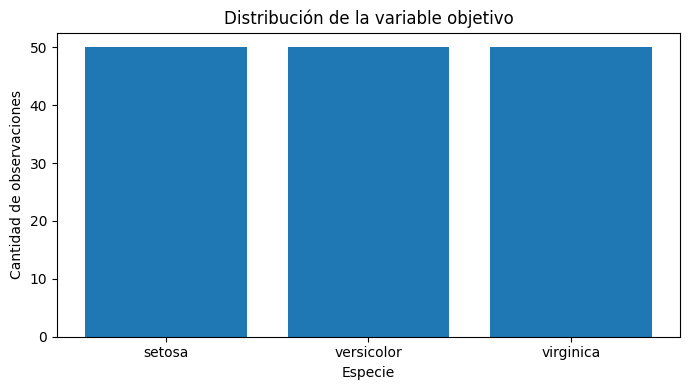

In [9]:
conteo = df_iris["Species"].value_counts(sort=False)

plt.figure(figsize=(7, 4))
plt.bar(conteo.index.astype(str), conteo.values)
plt.title("Distribución de la variable objetivo")
plt.xlabel("Especie")
plt.ylabel("Cantidad de observaciones")
plt.tight_layout()
plt.show()

### Interpretación

La distribución permite verificar si existe desbalance entre clases. En Iris, las tres especies presentan la misma cantidad de observaciones, por lo que no se identifica desbalance en esta revisión inicial.

# 8. Transformación y exploración inicial

Las siguientes actividades permiten comprender la distribución y relación de las variables. Se trata de evidencia exploratoria; no constituyen modelamiento.

## 8.1 Estadística descriptiva

In [10]:
# Estadística descriptiva de las variables numéricas
resumen_numerico = df_iris[columnas].describe().T
resumen_numerico["mediana"] = df_iris[columnas].median()
resumen_numerico["rango"] = resumen_numerico["max"] - resumen_numerico["min"]
display(resumen_numerico)

,count,mean,std,min,25%,50%,75%,max,mediana,rango
Sepal.Length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9,5.80,3.6
Sepal.Width,150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4,3.00,2.4
Petal.Length,150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9,4.35,5.9
Petal.Width,150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5,1.30,2.4


## 8.2 Análisis por especie

In [11]:
# Resumen por especie
resumen_por_especie = (
    df_iris
    .groupby("Species", observed=False)[columnas]
    .agg(["mean", "std", "min", "max"])
)
display(resumen_por_especie)

Sepal.Length                     Sepal.Width                      \
                   mean       std  min  max        mean       std  min  max   
Species                                                                       
setosa            5.006  0.352490  4.3  5.8       3.428  0.379064  2.3  4.4   
versicolor        5.936  0.516171  4.9  7.0       2.770  0.313798  2.0  3.4   
virginica         6.588  0.635880  4.9  7.9       2.974  0.322497  2.2  3.8   

           Petal.Length                     Petal.Width                      
                   mean       std  min  max        mean       std  min  max  
Species                                                                      
setosa            1.462  0.173664  1.0  1.9       0.246  0.105386  0.1  0.6  
versicolor        4.260  0.469911  3.0  5.1       1.326  0.197753  1.0  1.8  
virginica         5.552  0.551895  4.5  6.9       2.026  0.274650  1.4  2.5

### Interpretación

El resumen por especie permite comparar las características morfológicas
manteniendo `Species` en su naturaleza original de variable categórica nominal.

En el análisis descriptivo no es necesario asignar valores numéricos a las
especies. Posteriormente se generará una copia codificada de `Species`
exclusivamente para reproducir el procedimiento de correlación de Pearson
utilizado en el notebook de referencia. Esta codificación no modifica la
naturaleza conceptual de la variable objetivo.

## 8.3 Distribución y posibles valores atípicos

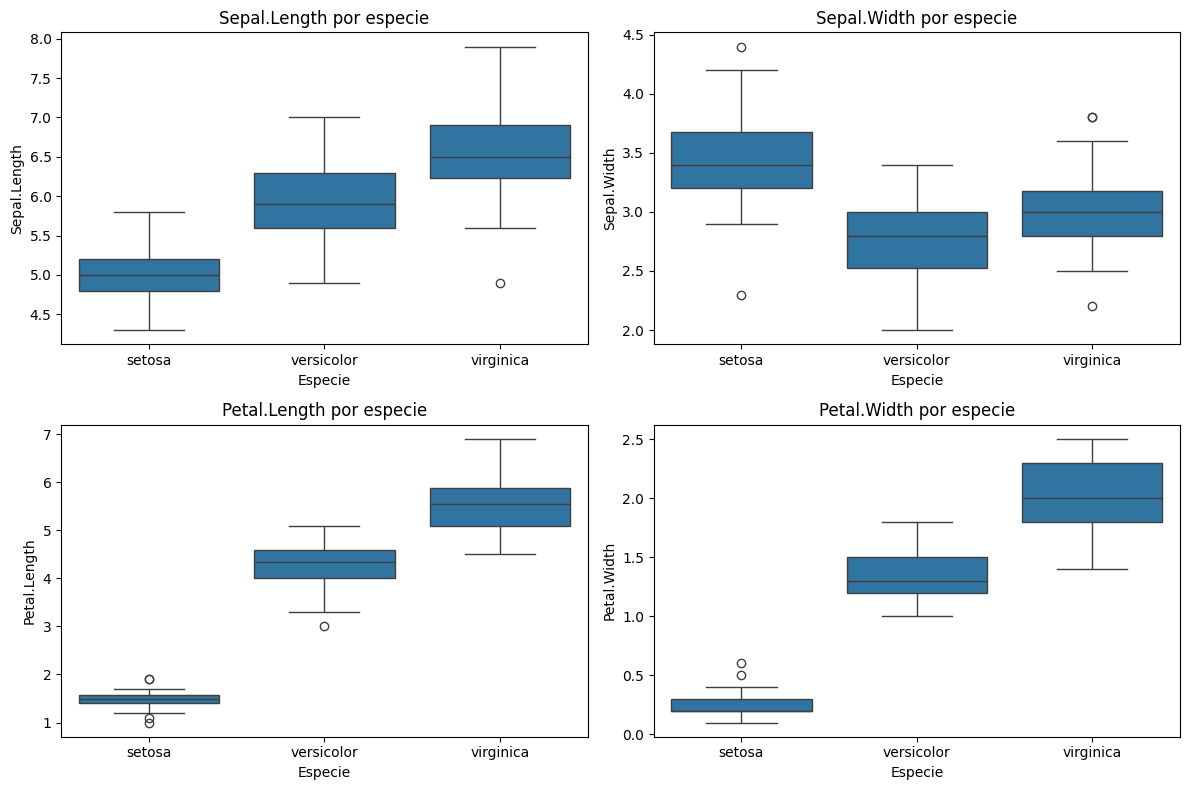

In [12]:
# Distribuciones y posibles valores atípicos
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, variable in zip(axes.flatten(), columnas):
    sns.boxplot(data=df_iris, x="Species", y=variable, ax=ax)
    ax.set_title(f"{variable} por especie")
    ax.set_xlabel("Especie")
    ax.set_ylabel(variable)
plt.tight_layout()
plt.show()

### Decisión sobre posibles atípicos

Los boxplots sirven para identificar observaciones extremas, pero no justifican por sí solos su eliminación. En esta fase se conservan, porque pueden representar variabilidad biológica legítima y no errores de medición.

## 8.4 Correlación de Pearson

Correspondencia utilizada para la codificación:
setosa: 1
versicolor: 2
virginica: 3


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
Sepal.Length,1.000,-0.118,0.872,0.818,0.783
Sepal.Width,-0.118,1.000,-0.428,-0.366,-0.427
Petal.Length,0.872,-0.428,1.000,0.963,0.949
Petal.Width,0.818,-0.366,0.963,1.000,0.957
Species,0.783,-0.427,0.949,0.957,1.000


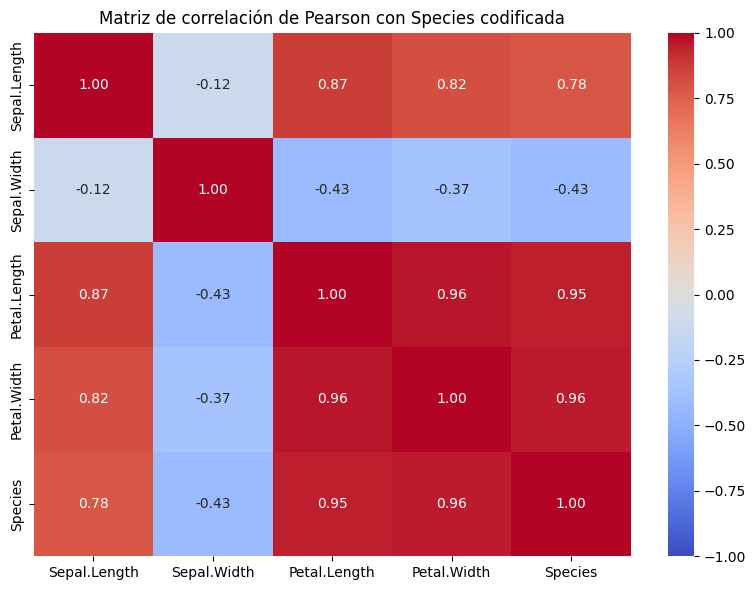

In [13]:
# Codificación numérica de la variable objetivo
# setosa = 1, versicolor = 2, virginica = 3

mapa_species = {
    "setosa": 1,
    "versicolor": 2,
    "virginica": 3
}

df_iris_codificado = df_iris.copy()
df_iris_codificado["Species"] = (
    df_iris_codificado["Species"]
    .astype(str)
    .map(mapa_species)
    .astype(int)
)

print("Correspondencia utilizada para la codificación:")
for especie, codigo in mapa_species.items():
    print(f"{especie}: {codigo}")

display(df_iris_codificado.head())

# Matriz de correlación de Pearson incluyendo Species codificada
columnas_correlacion = columnas + ["Species"]
matriz_correlacion = (
    df_iris_codificado[columnas_correlacion]
    .corr(method="pearson")
)

display(matriz_correlacion.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("Matriz de correlación de Pearson con Species codificada")
plt.tight_layout()
plt.show()


### Justificación de la inclusión de `Species`

La variable `Species` se codificó numéricamente de la siguiente manera:

- `setosa = 1`
- `versicolor = 2`
- `virginica = 3`

Esta transformación permite incluir `Species` en la matriz de correlación de Pearson junto con las cuatro variables morfológicas. Los coeficientes obtenidos permiten observar una asociación exploratoria entre el código asignado a la especie y las mediciones.

Sin embargo, `Species` sigue siendo conceptualmente una variable categórica nominal. Por ello, las correlaciones que la involucran deben interpretarse con precaución, ya que dependen del orden numérico asignado a las categorías y no representan una distancia cuantitativa entre las especies.


## 8.5 Significancia estadística mediante p-valores

In [14]:
from scipy.stats import pearsonr
import pandas as pd
import numpy as np

# Función para calcular la matriz de p-valores
def calcular_pvalores(df):
    columnas = df.columns
    pvalores = pd.DataFrame(
        np.ones((len(columnas), len(columnas))),
        columns=columnas,
        index=columnas
    )

    for i in range(len(columnas)):
        for j in range(len(columnas)):
            if i != j:
                _, p_value = pearsonr(
                    df[columnas[i]],
                    df[columnas[j]]
                )
                pvalores.iloc[i, j] = p_value

    return pvalores

columnas_correlacion = [
    "Sepal.Length",
    "Sepal.Width",
    "Petal.Length",
    "Petal.Width",
    "Species"
]

matriz_pvalores = calcular_pvalores(
    df_iris_codificado[columnas_correlacion]
)

display(matriz_pvalores.round(4))

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
Sepal.Length,1.0000,0.1519,0.0,0.0,0.0
Sepal.Width,0.1519,1.0000,0.0,0.0,0.0
Petal.Length,0.0000,0.0000,1.0,0.0,0.0
Petal.Width,0.0000,0.0000,0.0,1.0,0.0
Species,0.0000,0.0000,0.0,0.0,1.0


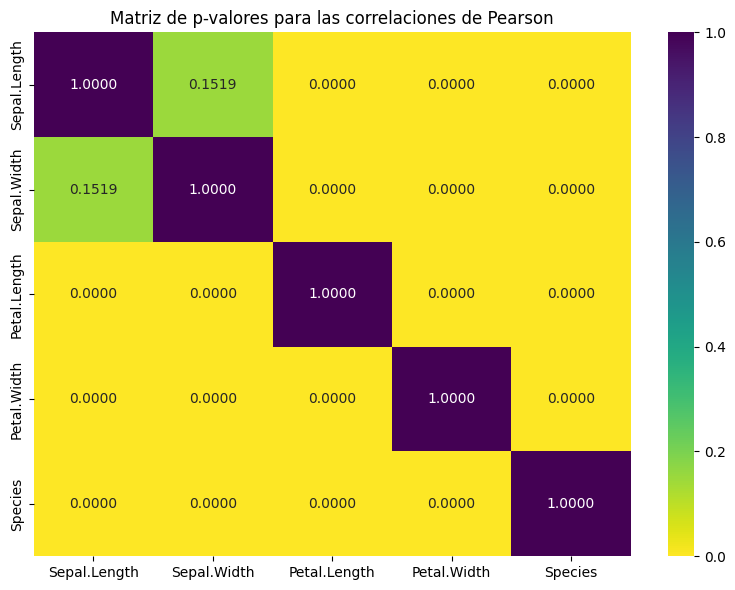

In [15]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_pvalores,
    annot=True,
    fmt=".4f",
    cmap="viridis_r"
)

plt.title("Matriz de p-valores para las correlaciones de Pearson")
plt.tight_layout()
plt.show()

### Interpretación de los p-valores

La matriz de p-valores complementa la matriz de correlación de Pearson,
permitiendo evaluar si las relaciones observadas son estadísticamente
significativas.

Los valores mostrados como `0.0000` corresponden a p-valores muy pequeños debido al redondeo utilizado y no deben interpretarse como un valor exactamente igual a cero.

Para cada correlación se consideran:

- **H₀:** no existe correlación lineal entre las variables.
- **H₁:** existe correlación lineal entre las variables.

Se utiliza un nivel de significancia de 0,05:

- Si `p < 0,05`, se considera que existe evidencia estadística de una
  relación lineal significativa entre las variables.
- Si `p ≥ 0,05`, no existe evidencia suficiente para afirmar que la
  correlación observada sea estadísticamente significativa.

Los p-valores deben analizarse junto con los coeficientes de correlación,
ya que una relación puede ser estadísticamente significativa, pero presentar
una intensidad baja.

En el caso de `Species`, los resultados deben interpretarse con cautela,
porque la variable fue codificada numéricamente como 1, 2 y 3 para reproducir
el procedimiento del notebook de referencia, aunque conceptualmente sigue
siendo una variable categórica nominal.

## 8.6 Transformación preliminar: normalización Min-Max

La normalización se muestra como una preparación posible para algoritmos sensibles a la escala, como KNN o SVM. No se declara todavía como transformación definitiva. En fases posteriores, el escalador deberá ajustarse exclusivamente con el conjunto de entrenamiento para evitar filtración de información.

In [16]:
scaler_exploratorio = MinMaxScaler()

df_normalizado = pd.DataFrame(
    scaler_exploratorio.fit_transform(df_iris[columnas]),
    columns=columnas,
    index=df_iris.index
)
df_normalizado["Species"] = df_iris["Species"]

display(df_normalizado.head())
display(df_normalizado[columnas].agg(["min", "max"]))

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,0.222222,0.625000,0.067797,0.041667,setosa
1,0.166667,0.416667,0.067797,0.041667,setosa
2,0.111111,0.500000,0.050847,0.041667,setosa
3,0.083333,0.458333,0.084746,0.041667,setosa
4,0.194444,0.666667,0.067797,0.041667,setosa


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
min,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0


### Decisión sobre la normalización

La salida confirma que las variables quedan en el intervalo [0, 1]. Sin embargo, su aplicación final dependerá del algoritmo seleccionado en fases posteriores. Los árboles de decisión, por ejemplo, no requieren escalamiento, mientras que los métodos basados en distancia sí pueden beneficiarse de él.

# 9. Comparación de enfoques

| Tipo de aprendizaje | Señal o dato asociado | Uso típico | Evaluación para Iris |
|---|---|---|---|
| **Supervisado** | Variables de entrada y etiquetas conocidas | Clasificación o regresión | **Seleccionado:** existen mediciones y una especie conocida por registro. |
| **No supervisado** | Variables sin etiqueta objetivo | Agrupamiento o reducción de dimensionalidad | Descartado como enfoque principal porque la meta es predecir especies conocidas. Puede usarse de forma complementaria para exploración. |
| **Por refuerzo** | Estados, acciones y recompensas | Decisiones secuenciales | Descartado porque no existe agente, entorno, acción ni recompensa. |

## 10. Documentación de decisiones técnicas

Durante el desarrollo de esta fase se adoptaron decisiones orientadas a mantener la coherencia entre la definición analítica del problema, la estructura del dataset, el enfoque de aprendizaje seleccionado y las etapas iniciales del proceso KDD.

| Decisión técnica | Justificación | Evidencia en el notebook |
|---|---|---|
| Utilizar el dataset Iris | El dataset contiene cuatro variables numéricas asociadas a características morfológicas y una variable objetivo categórica con tres clases conocidas. Su estructura permite formular un problema de clasificación supervisada multiclase. | Carga del dataset, visualización de sus primeras filas y revisión de su estructura. |
| Definir `Species` como variable objetivo | La finalidad analítica consiste en identificar la especie de una flor a partir de sus mediciones. Por ello, `Species` corresponde a la etiqueta que se proyecta predecir en fases posteriores. | Diccionario de variables y definición del enfoque de aprendizaje. |
| Utilizar las mediciones de sépalos y pétalos como variables predictoras | Las variables `Sepal.Length`, `Sepal.Width`, `Petal.Length` y `Petal.Width` representan atributos cuantitativos disponibles para caracterizar cada observación. | Selección de columnas numéricas y análisis descriptivo. |
| Seleccionar aprendizaje supervisado de clasificación multiclase | Cada registro cuenta con una etiqueta conocida y la variable objetivo posee tres categorías: `setosa`, `versicolor` y `virginica`. | Sección de clasificación del tipo de aprendizaje. |
| No desarrollar modelamiento en la Fase 1 | La fase se orienta a definir el problema, caracterizar los datos y justificar el enfoque metodológico. El entrenamiento y evaluación de algoritmos se reserva para etapas posteriores. | El notebook contiene exploración, preprocesamiento y transformación preliminar, sin entrenamiento de modelos. |
| Revisar valores nulos | La verificación de datos faltantes permite determinar si se requiere eliminación o imputación antes de continuar con el análisis. | Tabla de valores nulos por variable. |
| Revisar registros duplicados | La detección de duplicados permite documentar posibles repeticiones sin asumir automáticamente que corresponden a errores, ya que flores distintas podrían presentar mediciones iguales. | Conteo de registros duplicados. |
| Analizar la distribución de `Species` | La cantidad de observaciones por clase permite evaluar si existe desbalance en la variable objetivo. | Tabla de frecuencias y gráfico de distribución de especies. |
| Utilizar estadística descriptiva | Las medidas de tendencia central, dispersión y rango permiten caracterizar las variables y reconocer diferencias preliminares entre especies. | Resumen estadístico general y estadísticas agrupadas por `Species`. |
| Incorporar boxplots | Los diagramas de caja permiten observar la dispersión y detectar valores potencialmente atípicos en las variables morfológicas. | Boxplot de las variables numéricas. |
| Codificar `Species` como 1, 2 y 3 | Se transforma la variable `Species` siguiendo la siguiente codificación: `setosa = 1`, `versicolor = 2` y `virginica = 3`. Esta transformación permite incorporar `Species` en la matriz de correlación de Pearson. | Creación de `df_iris_codificado` y mapa de correspondencia de categorías. |
| Incluir `Species` en la matriz de Pearson | La variable codificada se incorpora para mantener correspondencia con el ejemplo docente y analizar de manera exploratoria su asociación con las mediciones. | Matriz y heatmap de correlación con las cinco variables. |
| Interpretar con cautela la correlación de `Species` | Aunque se representa mediante números, `Species` sigue siendo una variable categórica nominal. Por ello, sus coeficientes dependen del orden asignado a los códigos y no representan una distancia cuantitativa natural. | Nota metodológica posterior a la matriz de correlación. |
| Calcular p-valores para las correlaciones | Los p-valores complementan los coeficientes de Pearson y permiten evaluar si las relaciones observadas presentan significancia estadística bajo un nivel de `α = 0,05`. | Matriz y heatmap de p-valores. |
| Analizar conjuntamente coeficientes y p-valores | El coeficiente informa la fuerza y dirección de la relación, mientras que el p-valor permite evaluar su significancia. Ninguno debe interpretarse de forma aislada. | Interpretación posterior al análisis de significancia. |
| Aplicar normalización Min-Max de forma exploratoria | La transformación permite representar las variables en una escala común y anticipar una posible preparación para algoritmos sensibles a la escala. Su aplicación definitiva dependerá del modelo seleccionado en fases posteriores. | Creación de una copia normalizada de las variables predictoras. |
| Mantener trazabilidad entre informe, notebook y repositorio | Los nombres de las variables, el problema, los objetivos, el enfoque y las decisiones deben mantenerse consistentes en todos los componentes del proyecto. | Organización del notebook mediante secciones equivalentes a los apartados del informe y almacenamiento versionado en el repositorio. |

### Cambios realizados durante el desarrollo

Durante la construcción del notebook se realizaron ajustes respecto del código
de referencia inicial con el propósito de alinearlo con los requerimientos
de la Fase 1:

- Se incorporó la definición analítica del problema y la pregunta de análisis.
- Se agregaron el objetivo general y los objetivos específicos.
- Se identificaron formalmente las variables predictoras y la variable objetivo.
- Se explicitó la selección del aprendizaje supervisado de clasificación multiclase.
- Se estructuró el flujo de trabajo de acuerdo con las etapas de la metodología KDD.
- Se incorporó la revisión explícita de valores nulos y registros duplicados.
- Se agregó el análisis de distribución de la variable objetivo.
- Se incorporaron interpretaciones después de las principales salidas del código.
- Se aplica codificación numérica de `Species` como 1, 2 y 3 para reproducir
  el análisis de correlación.
- Se incorporó el análisis de p-valores como complemento de los coeficientes
  de correlación de Pearson.
- La normalización Min-Max se mantuvo únicamente como transformación preliminar,
  sin asumir que será utilizada por el modelo definitivo.

Estos cambios permiten establecer trazabilidad entre la definición conceptual
del problema y su implementación técnica en el notebook.

## 11. Conclusiones y proyección

El desarrollo de la Fase 1 permitió transformar el análisis del dataset Iris en un problema de ciencia de datos. La pregunta analítica se orienta a determinar si las características morfológicas de una flor, representadas por el largo y ancho de sus sépalos y pétalos, permiten diferenciar su especie.

A partir de la estructura de los datos se seleccionó un enfoque de aprendizaje supervisado de clasificación multiclase. Esta decisión se fundamenta en que cada observación contiene variables predictoras numéricas y una etiqueta conocida en la variable objetivo `Species`, compuesta por las clases `setosa`, `versicolor` y `virginica`.

La exploración inicial confirmó que el dataset contiene 150 observaciones,
cuatro variables numéricas continuas y una variable categórica objetivo.
No se identificaron valores nulos en ninguna de las variables. Se detectó
un registro duplicado exacto, correspondiente a dos observaciones de
`virginica` con las mismas mediciones; este se conservó debido a que la
igualdad de características no constituye por sí sola evidencia de un error
en los datos.

Asimismo, la variable objetivo presenta una distribución equilibrada:
`setosa`, `versicolor` y `virginica` contienen 50 observaciones cada una,
equivalentes al 33,33 % del conjunto de datos.

Siguiendo con el análisis, `Species` fue codificada numéricamente como 1, 2 y 3 e incorporada en la matriz de correlación de Pearson. Esto permitió analizar de forma exploratoria su asociación con las demás variables. No obstante, debido a que `Species` sigue siendo una variable categórica nominal, las correlaciones que la incluyen deben interpretarse con precaución, ya que dependen del orden asignado a la codificación.

Entre las variables numéricas se observa una relación positiva muy fuerte
entre `Petal.Length` y `Petal.Width` (r ≈ 0,96), mientras que la relación
entre `Sepal.Length` y `Sepal.Width` es débil (r ≈ -0,12). El análisis
de p-valores muestra además que esta última relación no presenta evidencia
de significancia estadística al nivel α = 0,05 (p ≈ 0,152).

El análisis de p-valores complementó la matriz de Pearson al permitir evaluar la significancia estadística de las relaciones observadas bajo un nivel de significancia de 0,05. Los resultados deben interpretarse conjuntamente: el coeficiente de Pearson indica la fuerza y dirección de la relación, mientras que el p-valor permite determinar si existe evidencia estadística suficiente para considerarla significativa.

La normalización Min-Max se incorporó como una transformación preliminar para representar las variables predictoras en una escala común. Esta decisión no implica que la transformación sea obligatoria para todos los algoritmos, ya que su utilización definitiva dependerá del modelo seleccionado en las siguientes fases.

En relación con la metodología KDD, esta fase abordó principalmente las etapas de selección, preprocesamiento, transformación e interpretación inicial. La etapa de modelamiento fue definida metodológicamente, pero no implementada, en concordancia con las instrucciones de la actividad.

Como proyección, en las fases posteriores se podrá:

1. dividir el dataset en conjuntos de entrenamiento y prueba;
2. evaluar algoritmos de clasificación supervisada;
3. comparar el desempeño de los modelos mediante métricas apropiadas;
4. analizar la influencia de las variables predictoras;
5. seleccionar el modelo que presente mejor capacidad de generalización;
6. interpretar los resultados y vincularlos con el objetivo analítico inicial.

En conclusión, las decisiones adoptadas muestran coherencia entre el problema, los datos, el tipo de aprendizaje y el proceso KDD.

# 12. Referencias

- Fayyad, U., Piatetsky-Shapiro, G., & Smyth, P. (1996). From data mining to knowledge discovery in databases. *AI Magazine, 17*(3), 37–54.
- pandas development team. (s. f.). *pandas documentation*. https://pandas.pydata.org/docs/
- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830.
- Ruete, D. (2026). Introducción al Machine Learning [Apunte]. Universidad Andrés Bello.
- Scikit-learn developers. (s. f.). *The Iris dataset*. Documentación de scikit-learn. https://scikit-learn.org/stable/auto_examples/decomposition/plot_pca_iris.html
- Universidad Andrés Bello. (2026). *MCDI504 Machine Learning I: Avance del proyecto — Fase 1, definición y orientación de la situación* [Material docente].